In [1]:
import pandas as pd

df = pd.read_csv("water_leak_detection_1000_rows 3.csv")

In [5]:
df.head()

,Timestamp,Sensor_ID,Pressure (bar),Flow Rate (L/s),Temperature (°C),Leak Status,Burst Status
0,2024-01-01 00:00:00,S007,3.694814,77.515218,21.695365,0,0
1,2024-01-01 00:05:00,S007,2.587125,179.926422,19.016725,0,0
2,2024-01-01 00:10:00,S002,2.448965,210.130823,10.011681,1,0
3,2024-01-01 00:15:00,S009,2.936844,141.777934,12.092408,0,0
4,2024-01-01 00:20:00,S003,3.073693,197.484633,17.001443,0,0


In [6]:
df['Sensor_ID'].nunique()

10

In [7]:
stats = df.groupby('Sensor_ID').describe()
print(stats)

          Pressure (bar)                                                    \
                   count      mean       std       min       25%       50%   
Sensor_ID                                                                    
S001                96.0  3.217324  0.453501  1.619930  2.914896  3.256448   
S002                95.0  3.222076  0.427686  2.448965  2.892327  3.214027   
S003                97.0  3.223257  0.522836  1.206346  2.823017  3.305895   
S004               100.0  3.242330  0.485948  1.066342  2.945866  3.274274   
S005                98.0  3.210480  0.561701  0.910977  2.848105  3.210538   
S006                96.0  3.211234  0.404903  2.519843  2.912949  3.191330   
S007               105.0  3.165926  0.515645  1.016992  2.750698  3.213055   
S008               101.0  3.236613  0.530665  1.052684  2.822411  3.298722   
S009               112.0  3.259090  0.498214  1.528541  2.927812  3.311785   
S010               100.0  3.216032  0.475736  1.612130  2.936974

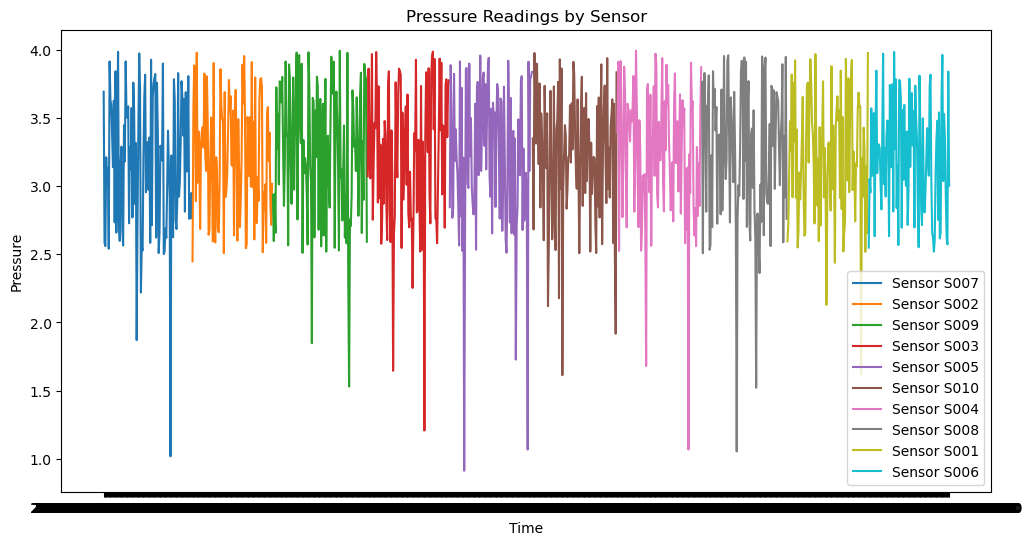

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sensor in df['Sensor_ID'].unique():
    subset = df[df['Sensor_ID'] == sensor]
    plt.plot(subset['Timestamp'], subset['Pressure (bar)'], label=f'Sensor {sensor}')

plt.xlabel('Time')
plt.ylabel('Pressure')
plt.title('Pressure Readings by Sensor')
plt.legend()
plt.show()

In [ ]:
pivot_df = df.pivot(index='Timestamp', columns='Sensor_ID', values='Pressure')
corr = pivot_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.title('Pressure Correlation Between Sensors')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.show()